In [2]:
import sys
import os
sys.path.append(os.path.abspath("../clean_code/"))

In [3]:
from Visualization import generalVisualization
from Visualization import mnistVisuals
from Visualization import visualHelpers
from Utilities import config
import pickle
import select_landmarks_MI
import importlib
import voltagemap
import main
import matplotlib.pyplot as plt
import numpy as np

In [4]:
importlib.reload(generalVisualization)
importlib.reload(mnistVisuals)
importlib.reload(visualHelpers)
importlib.reload(voltagemap)
importlib.reload(main)

<module 'main' from '/home/avighna/Documents/python/VoltageDimentionalReduction/clean_code/main.py'>

In [4]:
config.params['file_path']= '../../Voltage_Data/mnist/mnist.csv'
config.params['split_char']= ','
config.params['normalize_vecs']= False

config.params['max_centroids']= 1000
config.params['init_size']= 5000
config.params['batch_size']= 1000
config.params['kmeans_output']= '../../Voltage_Temp/Results/streaming_centroids.npy'
config.params['k']=2
config.params['r']=1

data_to_save = main.main()

Read 5000 vectors
Estimated max pairwise distance squared, FAISS) = 16295346.0000
 Estimated minimum distance squared = 89648.0000
10 vectors in index after adding initial centroid
Read 6000 vectors
number of centroids: 297, max_centroids: 1000
Read 7000 vectors
number of centroids: 456, max_centroids: 1000
Read 8000 vectors
number of centroids: 581, max_centroids: 1000
Read 9000 vectors
number of centroids: 731, max_centroids: 1000
Read 10000 vectors
number of centroids: 871, max_centroids: 1000
Read 11000 vectors
number of centroids: 995, max_centroids: 1000
Read 12000 vectors
number of centroids: 1000, max_centroids: 1000
Reached maximum number of centroids: 1000
Read 70000 vectorsmean d2= 1543434.8949250896
Closing reader...
Streaming K-means completed took 15.75 seconds
Compute voltages started took 0.00 seconds
<class 'setofpoints.SetOfPoints'>
all_voltages.all_solutions().shape: (1000, 1000)
Computed voltages for 1000 centroids took 116.01 seconds


In [5]:
data_to_save['voltage_map'] = select_landmarks_MI.select_landmarks(data_to_save['all_voltages'])

Adding landmark index=0 lm_index=441 with MI=0.6232
Adding landmark index=3 lm_index=516 with MI=1.1174
Adding landmark index=7 lm_index=120 with MI=1.5956
Adding landmark index=3 lm_index=345 with MI=2.0308
Adding landmark index=17 lm_index=956 with MI=2.4377
Adding landmark index=17 lm_index=155 with MI=2.8117
Adding landmark index=11 lm_index=212 with MI=3.2245
Adding landmark index=48 lm_index=472 with MI=3.5443
Adding landmark index=72 lm_index=844 with MI=3.8664
Adding landmark index=35 lm_index=475 with MI=4.0720


In [6]:
with open('../../Voltage_Temp/Results/voltage_map.npy', 'wb') as f:
    pickle.dump(data_to_save, f)

In [5]:
with open('../../Voltage_Temp/Results/voltage_map.npy', 'rb') as f:
    data_to_save = pickle.load(f)

In [6]:
voltage_map = voltagemap.VoltageMap()
for entry in data_to_save['voltage_map'].entries:
    voltage_map.add_solution(entry["landmark"], np.log(entry["voltages"]))

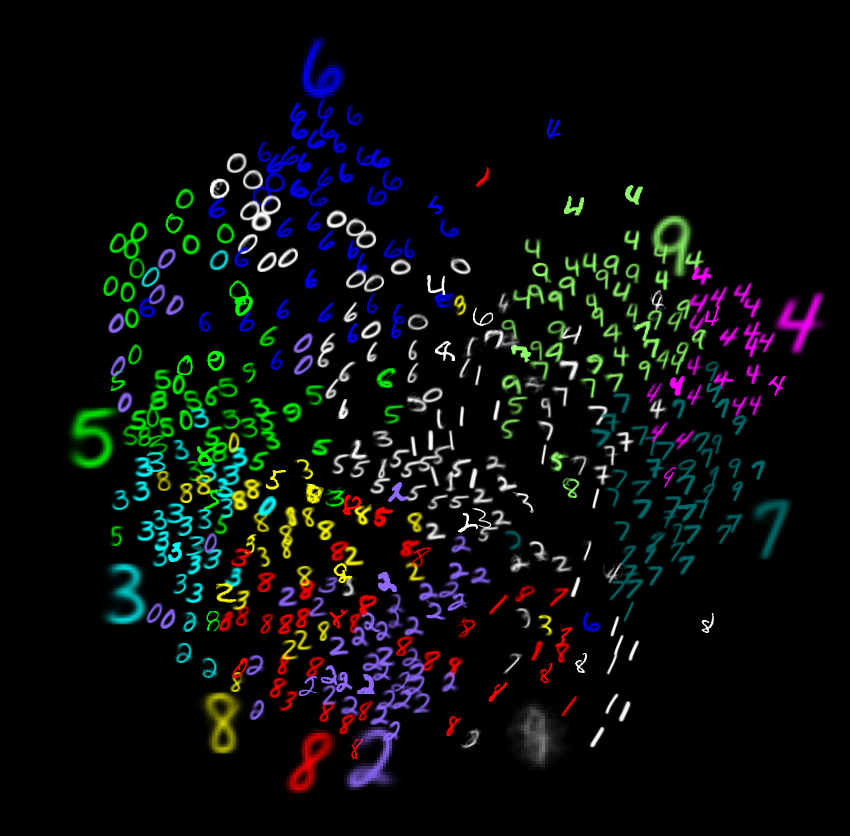

In [12]:
mnistVisuals.plot_mnist_unlabeled(voltage_map, data_to_save['centroids'], transformation="mds", argmax=True)

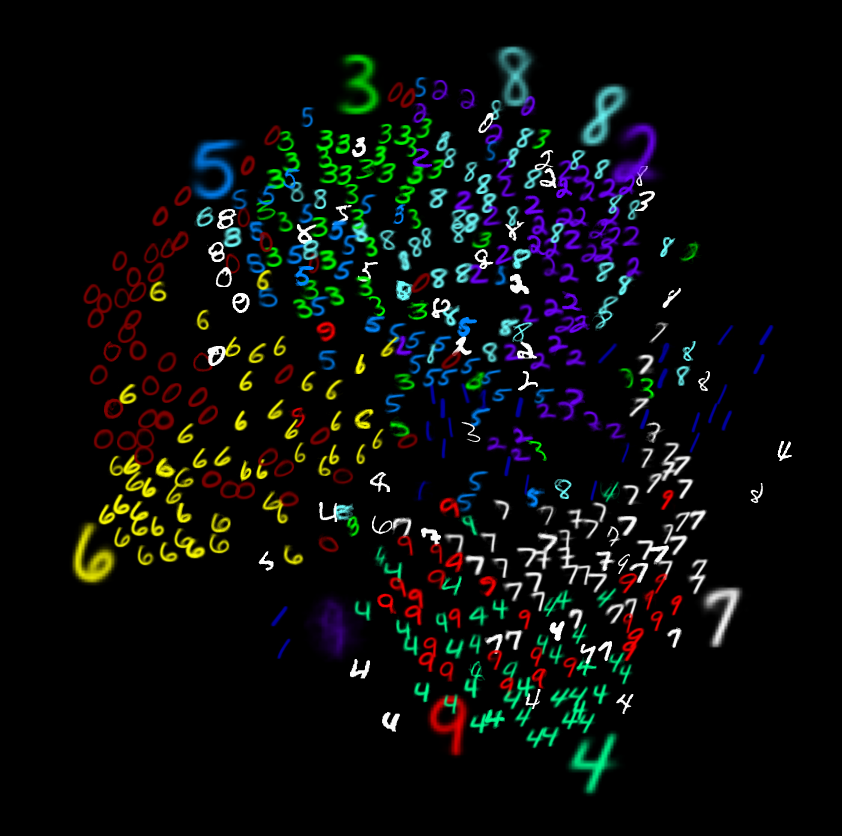

In [10]:
mnistVisuals.plot_mnist_digits(voltage_map, data_to_save['centroids'], data_to_save['majority_labels'])

In [10]:
def plot_with_landmarks_colored(data_to_save):
    va = data_to_save['voltage_map'].voltage_array()
    centroids = visualHelpers.transform(va, 'mds')
    all_voltages = data_to_save['all_voltages'].entries
    
    # Collect all landmark indices
    landmark_indices = {entry['landmark'].index for entry in all_voltages}

    plt.figure(figsize=(8, 6))
    for i, point in enumerate(centroids):
        if np.max(va[i]) == 1:
            plt.scatter(point[0], point[1], color='yellow', label='Landmark' if i == list(landmark_indices)[0] else "")
        else:
            plt.scatter(point[0], point[1], color='blue', s=10)

    plt.title("Centroid Points with Landmarks Highlighted")
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.legend()
    plt.grid(True)
    plt.show()

/tmp/ipykernel_33882/3270587395.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


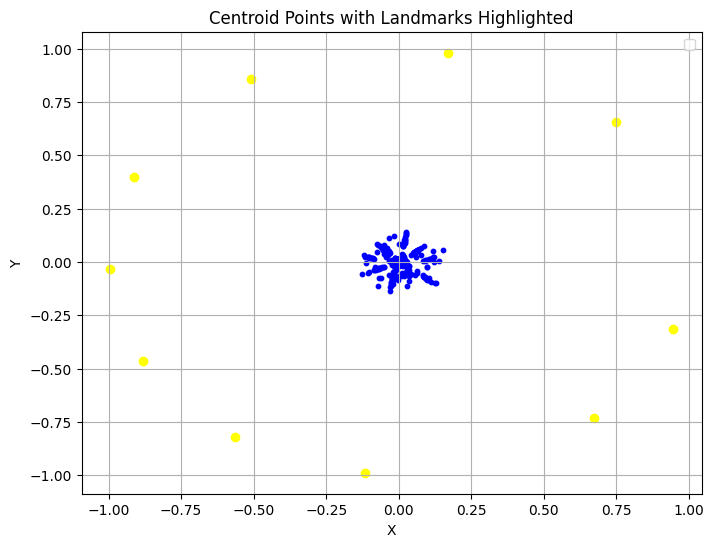

In [11]:
plot_with_landmarks_colored(data_to_save)